In [40]:
import torch
from torch.utils.data import DataLoader
from src.io.load import MasterDataset, _worker_init_fn
from src.gen.gen import create_mesh
from pathlib import Path

import numpy as np
import h5py
from src.io.hdf5_i import MasterReader
from src.viz.samples import (
    plot_topography,
    plot_density_contrast_3D_voxels,
    plot_gravity_measurements,
)

Available seeds: [0, 1, 2, 3, 4]


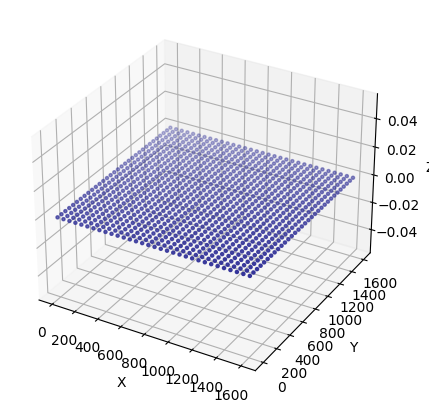

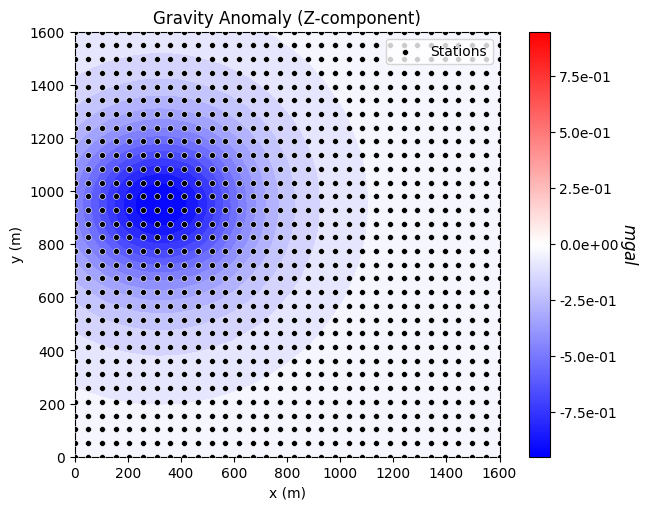

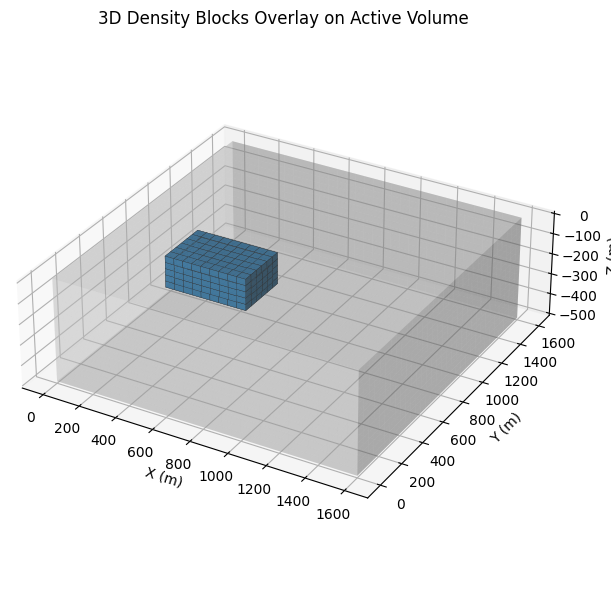

In [41]:
with MasterReader(Path("data/master.h5")) as mr:
    seeds = mr.list_seeds()
    print("Available seeds:", seeds[:5])   # show first 5

    sample = mr.read(seeds[4])

    gz = sample["gz"]
    true_model = sample["true_model"]
    ind_active = sample["ind_active"].astype(bool)
    receiver_locations = sample["receiver_locations"]
    plot_topography(receiver_locations)

    y = sample["gz"]
    true_model = sample["true_model"]
    plot_gravity_measurements(receiver_locations, y)

    full_model = np.zeros_like(ind_active, dtype=float)
    full_model[ind_active] = true_model
    blocks_mask = full_model > 0.0
    receiver_locations = np.flip(receiver_locations, axis=0)
    mesh = create_mesh(receiver_locations, n_xy=32, n_z=16, z_dom=500.0)
    plot_density_contrast_3D_voxels(mesh, ind_active, blocks_mask)

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [43]:
def to_tensors(sample):
    x = {"gz": torch.from_numpy(sample["gz"]).float()}
    ind_active = torch.from_numpy(sample["ind_active"]).bool()  
    nC = ind_active.numel()                                     
    y = torch.zeros(nC, dtype=torch.float32)
    y[ind_active] = torch.from_numpy(sample["true_model"]).float()
    return x, y

ds = MasterDataset("data/master.h5", transform=to_tensors)